In [1]:
import numpy as np 
import os
import sys
from osgeo import gdal, ogr, osr
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
sns.set_theme()

# import fastkml
from shapely import Polygon, box
import geopandas as gpd

# ====== import my own functions =========
import sys
import os
scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

from layers import assemble_data, get_aorc_layers
from validation import validate_date_pairs, validate_date

/Users/JULIALOBER/miniforge3/envs/coherence/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
data_dir = '../data/'

mcs_aoi = gpd.read_file(data_dir + 'mores_creek.shp')
mcs_aoi

,id,geometry
0,1,"POLYGON ((-115.6739 43.98328, -115.67315 43.98..."


In [3]:
mcs_lowman_05208_dates = ['200131_200213',
 '200131_200220',
 '200131_200311',
 '200131_210203',
 '200131_210210',
 '200131_210303',
 '200131_210310',
 '200131_210316',
 '200131_210322',
 '200213_200220',
 '200213_200311',
 '200213_210203',
 '200213_210210',
 '200213_210303',
 '200213_210310',
 '200213_210316',
 '200213_210322',
 '200220_200311',
 '200220_210203',
 '200220_210210',
 '200220_210303',
 '200220_210310',
 '200220_210316',
 '200220_210322',
 '200311_210203',
 '200311_210210',
 '200311_210303',
 '200311_210310',
 '200311_210316',
 '200311_210322',
 '210203_210210',
 '210203_210303',
 '210203_210310',
 '210203_210316',
 '210203_210322',
 '210210_210303',
 '210210_210310',
 '210210_210316',
 '210210_210322',
 '210303_210310',
 '210303_210316',
 '210303_210322',
 '210310_210316',
 '210310_210322',
 '210316_210322']

split_dates = [(part[0], part[1]) for part in [d.split('_') for d in mcs_lowman_05208_dates]]
# go from YYMMDD to YYYYMMDD
split_dates = [(f"20{date[0]}", f"20{date[1]}") for date in split_dates]
split_dates

[('20200131', '20200213'),
 ('20200131', '20200220'),
 ('20200131', '20200311'),
 ('20200131', '20210203'),
 ('20200131', '20210210'),
 ('20200131', '20210303'),
 ('20200131', '20210310'),
 ('20200131', '20210316'),
 ('20200131', '20210322'),
 ('20200213', '20200220'),
 ('20200213', '20200311'),
 ('20200213', '20210203'),
 ('20200213', '20210210'),
 ('20200213', '20210303'),
 ('20200213', '20210310'),
 ('20200213', '20210316'),
 ('20200213', '20210322'),
 ('20200220', '20200311'),
 ('20200220', '20210203'),
 ('20200220', '20210210'),
 ('20200220', '20210303'),
 ('20200220', '20210310'),
 ('20200220', '20210316'),
 ('20200220', '20210322'),
 ('20200311', '20210203'),
 ('20200311', '20210210'),
 ('20200311', '20210303'),
 ('20200311', '20210310'),
 ('20200311', '20210316'),
 ('20200311', '20210322'),
 ('20210203', '20210210'),
 ('20210203', '20210303'),
 ('20210203', '20210310'),
 ('20210203', '20210316'),
 ('20210203', '20210322'),
 ('20210210', '20210303'),
 ('20210210', '20210310'),
 

In [4]:
aoi = box(*mcs_aoi.total_bounds)
test_dates = [("20200101", "20200113"), 
         ("20200101", "20200129"),
         ("20200113", "20200129"),
         ("20210202", "20210214")]
dates_val = validate_date_pairs(split_dates)
fp_out = data_dir + 'stacks/mores_creek'
coh_dir = '/Users/JULIALOBER/snowex_uavsar_coherence/data/coherence/mcs/'

In [5]:
import s3fs
base_url = f's3://noaa-nws-aorc-v1-1-1km'
years = {2020, 2021}
s3_out = s3fs.S3FileSystem(anon=True)
# print(years)
fileset = [s3fs.S3Map(
                root=f"s3://{base_url}/{yr}.zarr", s3=s3_out, check=False
            ) for yr in years]
print(fileset)
ds_2021 = xr.open_mfdataset(fileset, engine='zarr')
print(ds_2021)

[<fsspec.mapping.FSMap object at 0x36940bb60>, <fsspec.mapping.FSMap object at 0x369442d50>]
<xarray.Dataset> Size: 40TB
Dimensions:              (time: 17544, latitude: 4201, longitude: 8401)
Coordinates:
  * time                 (time) datetime64[ns] 140kB 2020-01-01 ... 2021-12-3...
  * latitude             (latitude) float64 34kB 20.0 20.01 20.02 ... 54.99 55.0
  * longitude            (longitude) float64 67kB -130.0 -130.0 ... -60.01 -60.0
Data variables:
    APCP_surface         (time, latitude, longitude) float64 5TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    DLWRF_surface        (time, latitude, longitude) float64 5TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    DSWRF_surface        (time, latitude, longitude) float64 5TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    PRES_surface         (time, latitude, longitude) float64 5TB dask.array<chunksize=(144, 128, 256), meta=np.ndarray>
    SPFH_2maboveground   (time, latitude, longitude) fl

In [6]:
# merged = xr.concat([ds_2020, ds_2021], dim='time')
# merged

In [7]:
# clipped = merged.rio.clip(mcs_aoi.geometry.values, crs='EPSG:4326')
# plt.plot(clipped['time'], clipped['APCP_surface'].max(dim=['latitude', 'longitude']))

In [8]:
import pandas as pd
import xarray as xr

def report_time_gaps(ds, expected_freq='1h'):
    """
    Checks for missing timestamps in an xarray Dataset along the 'time' dimension.
    
    Parameters:
    ds (xr.Dataset): The dataset to check.
    expected_freq (str): The expected frequency (e.g., '1h' for hourly).
    """
    if 'time' not in ds.coords:
        print("Error: 'time' dimension not found in dataset.")
        return

    # Get the actual times from the dataset
    actual_times = pd.DatetimeIndex(ds.time.values)
    
    # Create the ideal timeline from the first to the last available timestamp
    ideal_times = pd.date_range(start=actual_times.min(), 
                                end=actual_times.max(), 
                                freq=expected_freq)
    
    # Find the difference
    missing_times = ideal_times.difference(actual_times)
    
    total_expected = len(ideal_times)
    total_missing = len(missing_times)
    
    print(f"--- Time Dimension Report ---")
    print(f"Expected Frequency: {expected_freq}")
    print(f"Start: {actual_times.min()}")
    print(f"End:   {actual_times.max()}")
    print(f"Total expected steps: {total_expected}")
    print(f"Missing steps: {total_missing}")
    
    if total_missing > 0:
        print(f"\nFirst 10 missing timestamps:")
        for t in missing_times[:10]:
            print(f"  - {t}")
        
        # Check for non-monotonicity (which caused your initial error)
        if not actual_times.is_monotonic_increasing:
            print("\nWARNING: Time index is NOT monotonically increasing!")
    else:
        print("\nSuccess: No missing time chunks detected.")

    return missing_times

def fix_aorc_dates(ds):
    # Filter out any dates from 1970 or any year that doesn't match the file
    # This keeps only the 'good' data
        return ds.sel(time=ds.time.dt.year > 1970)

In [9]:
# clipped['time'].values.min()

# # get 5 time values before and after the min
# min_time = clipped['time'].values.min()
# time_values = clipped['time'].values
# before_after_indices = []
# for i, t in enumerate(time_values):
#     if t == min_time:
#         before_after_indices.extend(range(max(0, i-5), min(len(time_values), i+6)))
#         break

# before_after_times = time_values[before_after_indices]
# before_after_times


In [10]:
# fix_aorc_dates(clipped)
report_time_gaps(ds_2021, expected_freq='1h')

--- Time Dimension Report ---
Expected Frequency: 1h
Start: 2020-01-01 00:00:00
End:   2021-12-31 23:00:00
Total expected steps: 17544
Missing steps: 0

Success: No missing time chunks detected.


DatetimeIndex([], dtype='datetime64[ns]', freq='h')

In [11]:
# aorc = get_aorc_layers(aoi=mcs_aoi, 
#                        date_pairs=validate_date_pairs(dates), 
#                        crs='EPSG:4326', 
#                        ref_grid=None)

In [12]:
data = assemble_data(aoi,
                    dates_val,
                    fp_out,
                    fp_coherence=coh_dir,
                    overwrite = True)
data

/Users/JULIALOBER/miniforge3/envs/coherence/lib/python3.13/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension pair because variable pair is not a coordinate. To create an index for pair, please first call `.set_coords('pair')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


<xarray.Dataset> Size: 96kB
Dimensions:      (pair: 45, x: 26, y: 20)
Coordinates:
  * pair         (pair) <U13 2kB '200131_200213' ... '210316_210322'
  * x            (x) float64 208B -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 160B 43.98 43.98 43.97 43.97 ... 43.92 43.91 43.91
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    coherence    (pair, y, x) float32 94kB nan nan nan nan ... nan nan nan nan


/Users/JULIALOBER/miniforge3/envs/coherence/lib/python3.13/site-packages/pygeoutils/pygeoutils.py:300: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge(


Got NLCD: <class 'xarray.core.dataset.Dataset'>
Got DEM: <class 'xarray.core.dataarray.DataArray'>
Got topo layers: <class 'xarray.core.dataset.Dataset'>
Got snow climatology: <class 'xarray.core.dataset.Dataset'>


QUEUEING TASKS | : 100%|██████████| 4/4 [00:00<00:00, 1002.76it/s]
PROCESSING TASKS | : 100%|██████████| 4/4 [00:01<00:00,  2.45it/s]
COLLECTING RESULTS | : 100%|██████████| 4/4 [00:00<00:00, 21760.33it/s]
/Users/JULIALOBER/snowex_uavsar_coherence/scripts/layers.py:475: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_days = ds.dims['Day']
/Users/JULIALOBER/snowex_uavsar_coherence/scripts/layers.py:475: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_days = ds.dims['Day']
/Users/JULIALOBER/snowex_uavsar_coherence/scripts/layers.py:475: FutureWarning: The return type of `Dataset.dims` wi

<xarray.Dataset> Size: 297kB
Dimensions:      (pair: 45, x: 26, y: 20)
Coordinates:
  * pair         (pair) <U13 2kB '200131_200213' ... '210316_210322'
  * x            (x) float64 208B -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 160B 43.98 43.98 43.97 43.97 ... 43.92 43.91 43.91
    band         int64 8B 1
    spatial_ref  int64 8B 0
    crs          int64 8B 0
Data variables:
    coherence    (pair, y, x) float32 94kB nan nan nan nan ... nan nan nan nan
    cover_2019   (y, x) uint8 520B 52 52 71 71 52 42 42 ... 42 52 42 42 52 52 52
    canopy_2019  (y, x) float32 2kB 0.0 0.0 0.0 11.0 14.0 ... 69.0 12.0 19.0 0.0
    elevation    (y, x) float32 2kB 2.368e+03 2.393e+03 ... 2.151e+03 2.085e+03
    slope        (y, x) float32 2kB 9.666 13.45 3.886 ... 21.88 20.76 23.85
    aspect       (y, x) float32 2kB 206.5 198.5 125.0 ... 37.39 35.99 27.13
    curve        (y, x) float32 2kB -0.0 -0.0 0.06983 ... -0.0 -0.0128 -0.0
    snow_class   (y, x) float32 2kB 1.0 2.0 1.0 5.0 6.0 ... 6.0 6.0 6.0 5.0 5.0
    swe_change   (pair, y, x) float32 94kB 0.1132 0.0932 ... -0.0092 0.0116
    sd_change    (pair, y, x) float32 94kB 0.099 0.1566 ... -0.0704 0.0554

In [ ]:
print(data)

<xarray.Dataset> Size: 30kB
Dimensions:      (x: 26, y: 20, pair: 4)
Coordinates:
  * x            (x) float64 208B -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 160B 43.98 43.98 43.97 43.97 ... 43.92 43.91 43.91
  * pair         (pair) <U17 272B '20200101_20200113' ... '20210202_20210214'
    spatial_ref  int64 8B 0
    band         int64 8B 1
    crs          int64 8B 0
Data variables:
    cover_2019   (y, x) uint8 520B 52 52 71 71 52 42 42 ... 42 52 42 42 52 52 52
    canopy_2019  (y, x) float32 2kB 0.0 0.0 0.0 11.0 14.0 ... 69.0 12.0 19.0 0.0
    elevation    (y, x) float32 2kB 2.368e+03 2.393e+03 ... 2.151e+03 2.085e+03
    slope        (y, x) float32 2kB 9.666 13.45 3.886 ... 21.88 20.76 23.85
    aspect       (y, x) float32 2kB 206.5 198.5 125.0 ... 37.39 35.99 27.13
    curve        (y, x) float32 2kB -0.0 -0.0 0.06983 ... -0.0 -0.0128 -0.0
    snow_class   (y, x) float32 2kB 1.0 2.0 1.0 5.0 6.0 ... 6.0 6.0 6.0 5.0 5.0
    swe_change   (pair, y, x) 

/var/folders/vr/54bwt92x0tq5_lsckcv161380000gp/T/ipykernel_70638/1108996813.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


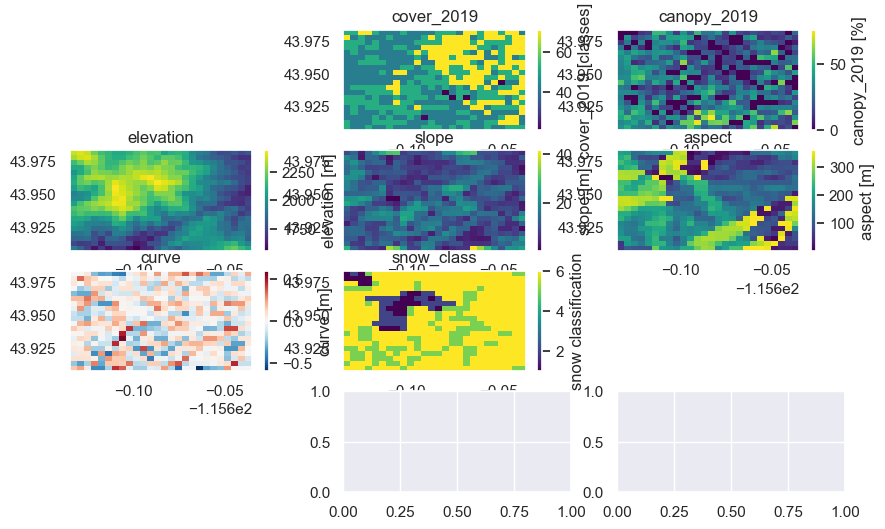

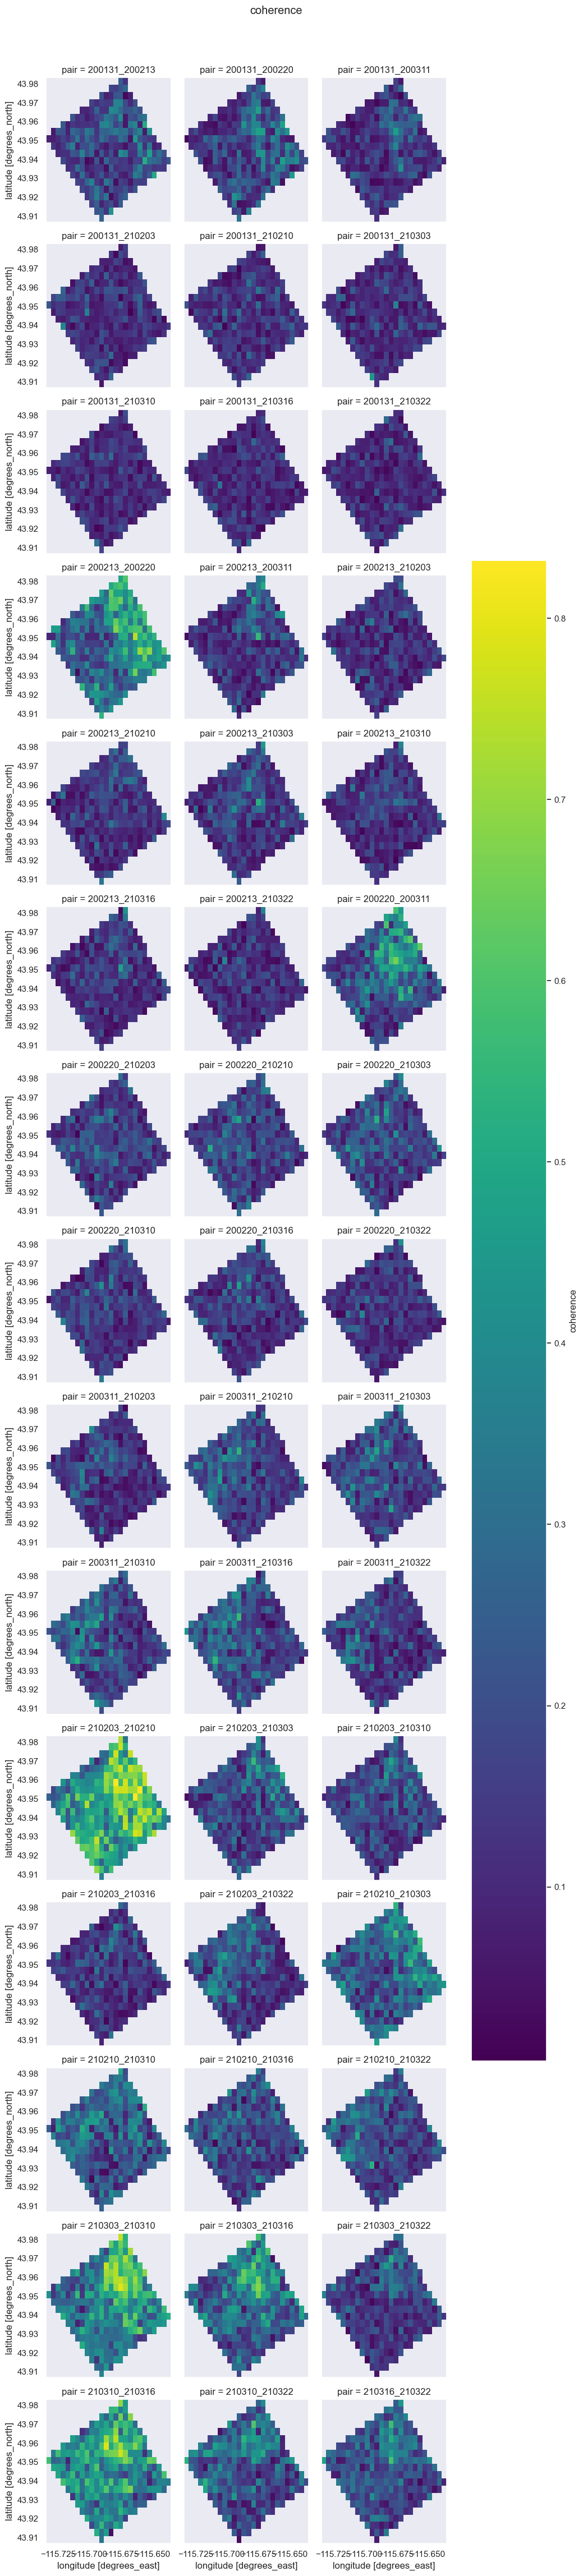

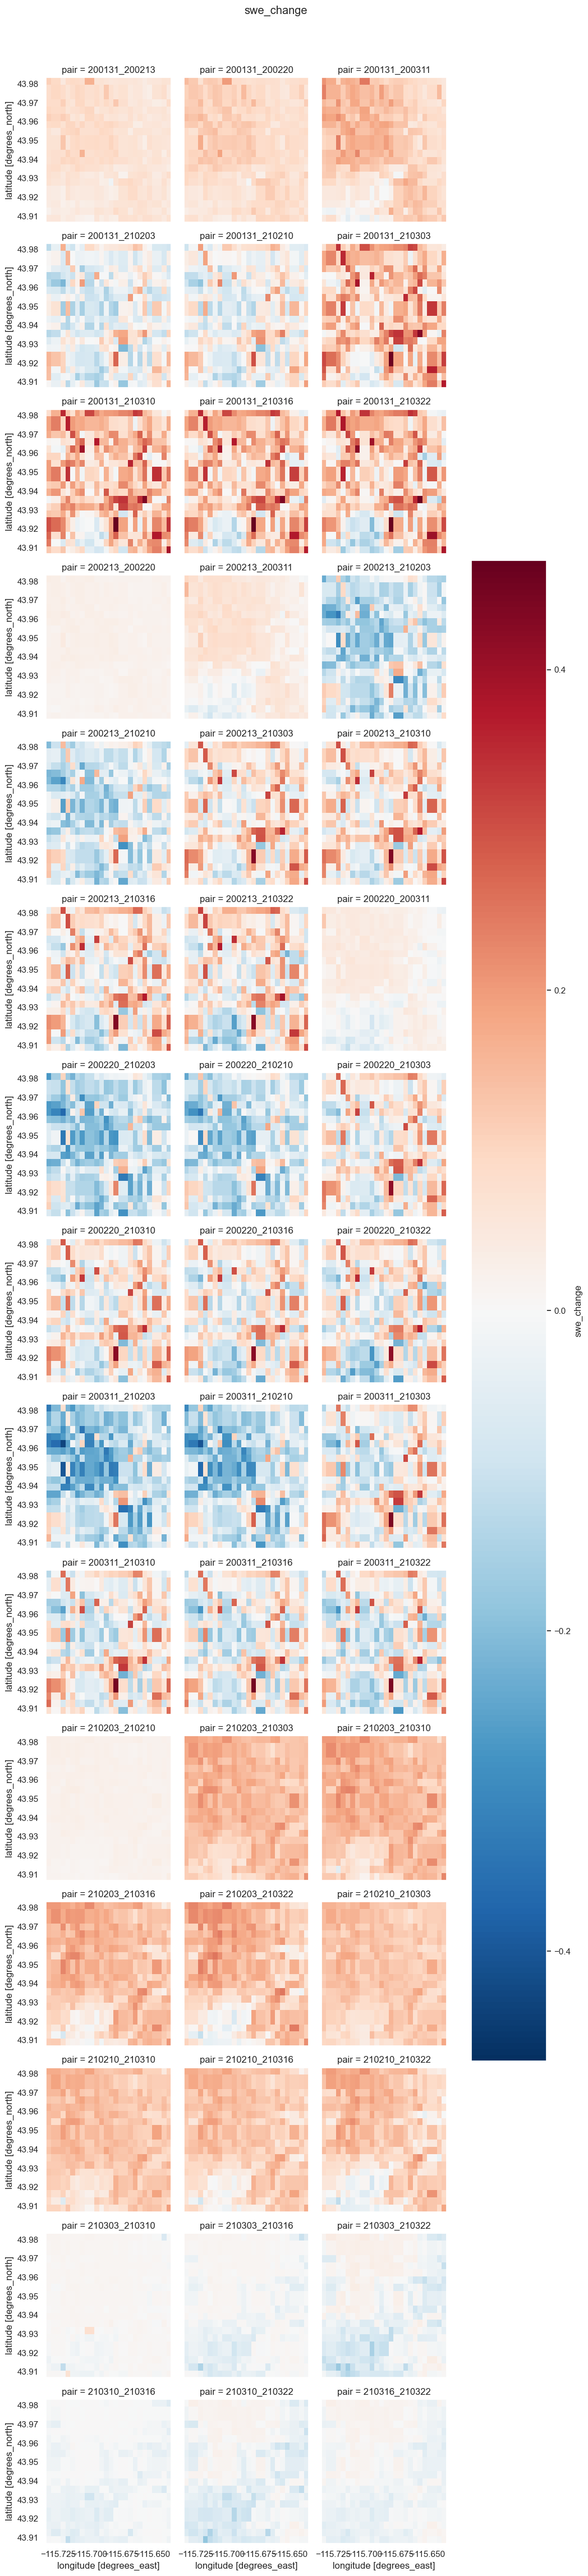

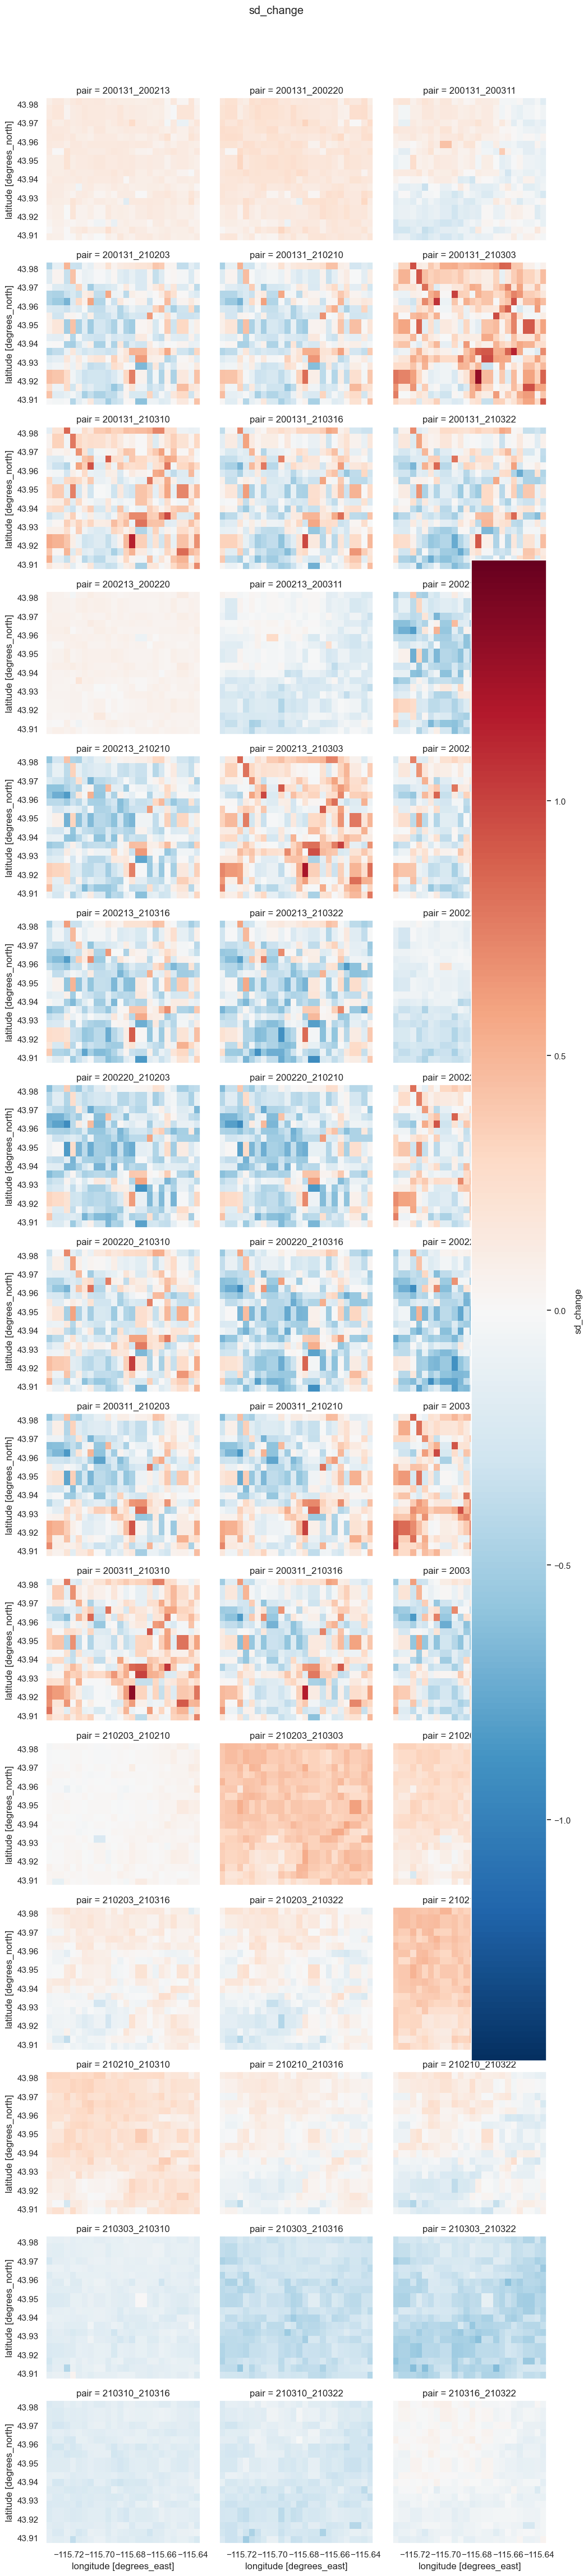

In [13]:
n = len(data)
fig, axes = plt.subplots(int(np.ceil(n / 3)), 3, figsize = (10, 6))
axes = axes.flatten()

for i, var in enumerate(data.data_vars): 
    # print(var, i)
    # print(data[var])
    data[var].plot(ax=axes[i])
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    if 'pair' in data[var].dims:
        axes[i].set_visible(False)  # hide the placeholder axis in the main grid
        data[var].plot(
            col='pair',
            col_wrap=3,
            figsize=(10, 3 * int(np.ceil(data.sizes['pair'] / 3)))
        )
        plt.suptitle(var, y=1.02)
        # plt.tight_layout()
        # plt.show()
    # break

plt.tight_layout()
plt.show()